In [1]:
'''
PREUGUNTA DE INTERES: ¿QUIEN DEBERIA HABER SIDO EL MVP DE LA TEMPORADA 22/23 DE LA NBA?
'''

'\nPREUGUNTA DE INTERES: ¿QUIEN DEBERIA HABER SIDO EL MVP DE LA TEMPORADA 22/23 DE LA NBA?\n'

In [2]:
#Importamos todas las librerias que seran usadas en todo el codigo
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np
import matplotlib.lines as mlines
import seaborn as sns
import openpyxl 

In [3]:
#Leemos el CSV original

df= pd.read_csv("2023_nba_player_stats.csv")

In [4]:
stats_sum = [
    "PTS","FG%","3P%","FT%",
    "OREB","DREB","REB","AST","TOV","STL","BLK","PF","+/-","Min"]

# Creamos un nuevo DataFrame solo con stats por partido
df_per_game = df[["PName","Team","POS","GP","Min","W"]].copy()

# Lista de columnas que son porcentajes
percent_cols = ["FG%", "3P%", "FT%"]   # agregá las que tengas en tu df

for col in stats_sum:
    if col in df.columns:
        if col in percent_cols:
            # Si es porcentaje, lo dejamos igual
            df_per_game[f"{col}"] = df[col]
        else:
            # Si no es porcentaje, lo pasamos a por-partido
            df_per_game[f"{col}_PG"] = (df[col] / df["GP"]).round(2)


In [5]:
'''
Filtrar jugadores relevantes para el MVP
La NBA filtra los jugadores con mas de 60 partidos
El MVP con menor cantidad de minutos jugados es 30.4, por lo que 25 minutos de minimo nos parecio un buen filtro
El MVP con menor cantidad de puntos por partido en una temporada es de 13.4, por lo que 10 puntos por partido es buen numero para hacer un corte
'''
df_per_game_filtrado = df_per_game[(df_per_game["GP"]>60) & (df_per_game["Min_PG"]>25) & (df_per_game["PTS_PG"]>10)]



In [6]:

def per36_df(df,
                name_col="PName", team_col="Team", pos_col="POS",
                min_col="Min_PG", decimals=2):
    """
    Crea y devuelve una NUEVA tabla con stats normalizadas a 36 minutos,
    sin modificar el DataFrame original.

    Requiere (por partido): PTS_PG, FGM_PG, FGA_PG, 3PA_PG, DREB_PG, REB_PG,
                            AST_PG, TOV_PG, STL_PG, BLK_PG, PF_PG, Min_PG
    Opcionales: FTM_PG, FTA_PG, 3PM_PG, ORB_PG
    """

    df_in = df.copy()  # no tocamos el original

    # Factor per-36 (si Min_PG=0 -> NaN -> 0)
    fac36 = 36 / df_in[min_col].replace(0, np.nan)

    # Rebote ofensivo si no viene explícito
    if "ORB_PG" in df_in.columns:
        ORB_PG = df_in["ORB_PG"]
    else:
        ORB_PG = df_in["REB_PG"] - df_in["DREB_PG"]


    # Construimos las columnas per-36
    per36 = pd.DataFrame({
        name_col: df_in[name_col],
        team_col: df_in[team_col],
        pos_col:  df_in[pos_col],
        "GP": df_in["GP"],
        "W": df_in["W"],
        "PTS36":       df_in["PTS_PG"] * fac36,
        "FT%":          df_in["FT%"],
        "3P%":          df_in["3P%"],
        "FG%":          df_in["FG%"],
        "ORB36":       ORB_PG * fac36,
        "DRB36":       df_in["DREB_PG"] * fac36,
        "AST36":       df_in["AST_PG"]  * fac36,
        "STL36":       df_in["STL_PG"]  * fac36,
        "BLK36":       df_in["BLK_PG"]  * fac36,
        "TOV36":       df_in["TOV_PG"]  * fac36,
        "PF36":        df_in["PF_PG"]   * fac36,
     
        "+/-36":       df_in["+/-_PG"]  *fac36
    })


    # Limpiar Inf/NaN (casos con Min_PG == 0)
    per36 = per36.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Redondeo suave
    float_cols = per36.select_dtypes(include=[np.number]).columns
    per36[float_cols] = per36[float_cols].round(decimals)

    return per36



In [7]:
df_normalizado =per36_df(df_per_game_filtrado)

In [8]:
df_normalizado["POS"].unique()
df_normalizado[(df_normalizado["POS"]=="F") | (df_normalizado["POS"]=="G")]

,PName,Team,POS,GP,W,PTS36,FT%,3P%,FG%,ORB36,DRB36,AST36,STL36,BLK36,TOV36,PF36,+/-36
79,Christian Wood,DAL,F,67,33,23.07,77.2,37.6,51.5,1.80,8.37,2.51,0.62,1.48,2.51,3.50,-0.96
87,Jalen Williams,OKC,F,75,36,16.71,81.2,35.6,52.1,1.33,4.00,3.93,1.63,0.56,1.95,3.03,-0.84
90,Kenyon Martin Jr.,HOU,F,82,22,16.32,68.0,31.5,56.9,1.97,5.13,1.93,0.64,0.48,1.43,2.31,-5.78
96,Luguentz Dort,OKC,G,74,36,16.05,77.2,33.0,38.8,2.03,3.42,2.44,1.18,0.36,1.45,3.85,0.54
99,Bobby Portis,MIL,F,70,47,19.54,76.8,37.0,49.6,3.05,10.25,2.08,0.57,0.32,1.61,2.27,0.33


In [9]:


 #Se modifican las posiciones de los jugadores que tenian NaN con la posicion que figura en la pagina del equipo(Tenian NaN porque estaba 
# generalizado en F(incluye SF,PF y C) y G(PG y SG))
df_normalizado.loc[df_normalizado["PName"].eq("Bobby Portis"), "POS"] = "C"
df_normalizado.loc[df_normalizado["PName"].eq("Luguentz Dort"), "POS"] = "SG"
df_normalizado.loc[df_normalizado["PName"].eq("Jalen Williams"), "POS"] = "SF"
df_normalizado.loc[df_normalizado["PName"].eq("Christian Wood"), "POS"] = "C"
df_normalizado.loc[df_normalizado["PName"].eq("Kenyon Martin Jr."), "POS"] = "C"


In [10]:
#Se ordena el dataframe normalizado por posicion
order=["PG","SG","SF","PF","C"]
cat = pd.CategoricalDtype(categories=order, ordered=True)

df_normalizado["POS"] = df_normalizado["POS"].astype(cat)
df_normalizado.sort_values("POS", inplace=True)
df_normalizado.reset_index(drop=True, inplace=True )  # no te deja la col 'index'

In [11]:
# Se le aplica al Dataframe normalizado una formula de eficiencia para determinar que jugador es mas eficiente
# La formula fue determinada por nosotros, luego de investigar como se valuan las caracteristicas en la NBA 

df_normalizado["REB36"] = df_normalizado["DRB36"] + df_normalizado["ORB36"]

df_normalizado["EFF"] = (
    df_normalizado["PTS36"]*1.3
    + df_normalizado["REB36"] *0.6
    + df_normalizado["AST36"] * 1.2
    + df_normalizado["STL36"] * 1.5
    + df_normalizado["BLK36"] * 1.5
    + df_normalizado["FG%"] * 0.6
    + df_normalizado["3P%"] * 0.4
    + df_normalizado["FT%"] * 0.2
    - (df_normalizado["TOV36"] * 2)
    - (df_normalizado["PF36"] * 0.5)
    + (df_normalizado["+/-36"] * 0.7)
)

# Ordenar por eficiencia
df_normalizado = df_normalizado.sort_values("EFF", ascending=False).reset_index().drop(columns="index")


In [12]:
#Se seleccionan a los tres jugadores que estan en el borde superior derecho, porque se visualiza la amplia diferencia de los tres con el resto.
#Se hara un nuevo dataframe con sus estadisticas de los tres jugadores por partidos.

In [13]:
df_top3=df_per_game[df_per_game["PName"].isin(["Nikola Jokic","Giannis Antetokounmpo","Joel Embiid"])]
df_top3.reset_index(inplace=True)
df_top3=df_top3.drop(columns=["index","Min"])

In [14]:
#Se hacen las conversiones de posiciones en otro dataframe para poder realizar una media de cada posicion
df_per_game_filtrado.loc[df_per_game_filtrado["PName"].eq("Bobby Portis"), "POS"] = "C"
df_per_game_filtrado.loc[df_per_game_filtrado["PName"].eq("Luguentz Dort"), "POS"] = "SG"
df_per_game_filtrado.loc[df_per_game_filtrado["PName"].eq("Jalen Williams"), "POS"] = "SF"
df_per_game_filtrado.loc[df_per_game_filtrado["PName"].eq("Christian Wood"), "POS"] = "C"
df_per_game_filtrado.loc[df_per_game_filtrado["PName"].eq("Kenyon Martin Jr."), "POS"] = "C"

In [15]:
df_media= df_per_game_filtrado.groupby("POS").mean(numeric_only=True)
df_media.drop(columns=["Min","GP","PF_PG"],inplace=True)
df_media["STL_BLK_PG"] = df_media["BLK_PG"] + df_media["STL_PG"]

In [16]:
# Nombres de archivo = nombres de jugadores
players = ["Nikola Jokic", "Joel Embiid", "Giannis Antetokounmpo"]

# Diccionario para guardar los DataFrames
dfs = {}

for player in players:
    file_name = f"{player}.xlsx"   # cada archivo se llama igual al jugador
    df = pd.read_excel(file_name)  # leer el Excel
    dfs[player] = df               # guardarlo en un diccionario
    print(f"✅ Dataset cargado: {file_name} ({df.shape[0]} filas, {df.shape[1]} columnas)")

# Ahora podés acceder a cada DataFrame así:
df_jokic = dfs["Nikola Jokic"]
df_embiid = dfs["Joel Embiid"]
df_giannis = dfs["Giannis Antetokounmpo"]

✅ Dataset cargado: Nikola Jokic.xlsx (137 filas, 21 columnas)
✅ Dataset cargado: Joel Embiid.xlsx (131 filas, 21 columnas)
✅ Dataset cargado: Giannis Antetokounmpo.xlsx (125 filas, 21 columnas)


In [17]:
df_jokic.dropna(subset="Min", inplace=True)
df_jokic.reset_index(inplace=True)
df_jokic.drop(columns="index",inplace=True)
df_giannis.dropna(subset="Min", inplace=True)
df_giannis.reset_index(inplace=True)
df_giannis.drop(columns="index",inplace=True)
df_embiid.dropna(subset="Min", inplace=True)
df_embiid.reset_index(inplace=True)
df_embiid.drop(columns="index",inplace=True)

In [18]:
top10_teams=["Boston Celtics","Milwaukee Bucks","Philadelphia 76ers", "Cleveland Cavaliers","New York Knicks","Brooklin Nets","Denver Nuggets","Memphis Grizzlies","Sacramento Kings","Phoenix Suns"]

# Función para detectar si el partido fue contra un top10
def vs_top10(equipo):
    for team in top10_teams:
        if team in str(equipo):  # busca coincidencia en la cadena
            return True
    return False

# Filtrar dataset
df_top10_embiid = df_embiid[df_embiid["Partido"].apply(vs_top10)].copy()
df_top10_jokic = df_jokic[df_jokic["Partido"].apply(vs_top10)].copy()
df_top10_giannis= df_giannis[df_giannis["Partido"].apply(vs_top10)].copy()



C:\Users\ftamaki\AppData\Local\Temp\ipykernel_4004\1493740111.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)


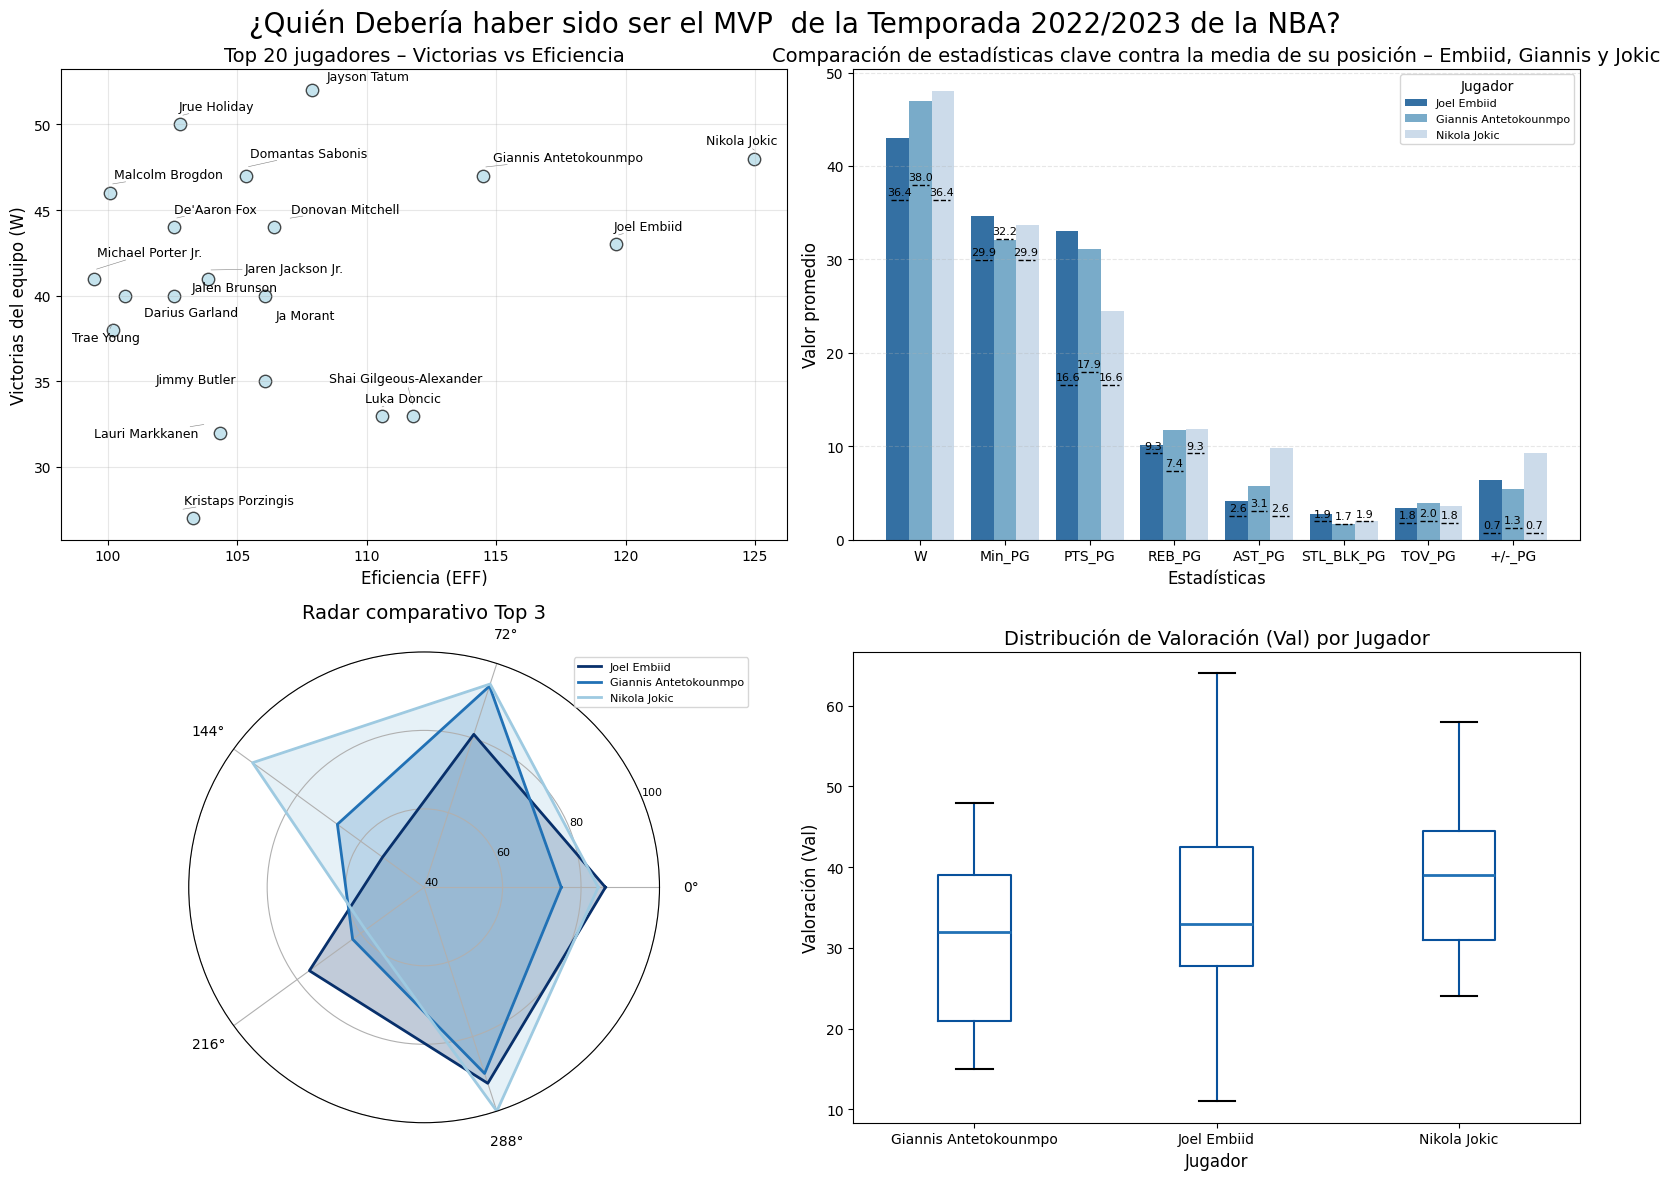

In [21]:
fig = plt.figure(figsize=(16, 12))

# ================================
# 1) SCATTER TOP 20 (arriba izquierda)
ax1 = fig.add_subplot(2, 2, 1)
top20 = df_normalizado.sort_values("EFF", ascending=False).head(20)
ax1.scatter(
    top20["EFF"], top20["W"],
    color="lightblue", alpha=0.7, s=80, edgecolors="k"
)
texts = []
for i, player in enumerate(top20["PName"]):
    x, y = top20["EFF"].iloc[i], top20["W"].iloc[i]

     # offsets manuales para casos conflictivos
    if "DeRozan" in player:
        texts.append(plt.text(x -0.5, y + 1.2, player, fontsize=9, ha="center")) 
    elif "Brunson" in player:
        texts.append(plt.text(x, y +1, player, fontsize=9, ha="center"))  
    elif "Morant" in player:
        texts.append(plt.text(x , y - 1, player, fontsize=9, ha="left"))  
    elif "Porzingis" in player:
        texts.append(plt.text(x - 0.5, y + 0.5 , player, fontsize=9, ha="right")) 
    elif "Mitchell" in player:
        texts.append(plt.text(x + 0.5, y +0.5 , player, fontsize=9, ha="right")) 
    elif "Markkanen" in player:
        texts.append(plt.text(x - 0.5, y +0.5 , player, fontsize=9, ha="right")) 
    elif "Butler" in player:
        texts.append(plt.text(x -0.5, y +0.5  , player, fontsize=9, ha="right")) 
    elif "Garland" in player:
        texts.append(plt.text(x , y -1.2 , player, fontsize=9, ha="right")) 
    else:
        texts.append(plt.text(x, y + 0.5, player, fontsize=9, ha="center"))
   
adjust_text(
    texts, x=top20["EFF"], y=top20["W"],
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.4),
    ax=ax1
)
ax1.set_xlabel("Eficiencia (EFF)", fontsize=12)
ax1.set_ylabel("Victorias del equipo (W)", fontsize=12)
ax1.set_title("Top 20 jugadores – Victorias vs Eficiencia", fontsize=14, weight="medium")
ax1.grid(alpha=0.3)

# ================================
# 2) BARPLOT (arriba derecha)
ax2 = fig.add_subplot(2, 2, 2)
df_top3["STL_BLK_PG"] = df_top3["BLK_PG"] + df_top3["STL_PG"]
stats_clean = ["W","Min_PG","PTS_PG", "REB_PG", "AST_PG", "STL_BLK_PG", "TOV_PG","+/-_PG"]
df_filtrado = df_top3.set_index("PName")[stats_clean]
df_long = df_filtrado.reset_index().melt(id_vars="PName", var_name="Estadística", value_name="Valor")

sns.barplot(
    data=df_long, x="Estadística", y="Valor", hue="PName",
    palette=sns.color_palette("Blues_r", n_colors=3), ax=ax2
)
ax2.set_title("Comparación de estadísticas clave contra la media de su posición – Embiid, Giannis y Jokic", fontsize=14, weight="medium")
ax2.set_ylabel("Valor promedio", fontsize=12)
ax2.set_xlabel("Estadísticas", fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="Jugador", loc="upper right", fontsize=8)
ax2.grid(axis="y", alpha=0.3, linestyle="--")

# Diccionario jugador -> posición
posiciones = {
    "Joel Embiid": "C",
    "Giannis Antetokounmpo": "PF",
    "Nikola Jokic": "C"
}

# Iteramos sobre las barras
for i, stat in enumerate(stats_clean):
    for j, jugador in enumerate(posiciones.keys()):
        pos = posiciones[jugador]
        if stat in df_media.columns:
            media_valor = df_media.loc[pos, stat]

            # La barra está en la posición i + desplazamiento por jugador
            x_bar = i + (j - 1) * 0.25  # 0.25 es el ancho aprox de cada barra

            # Dibujar línea corta solo sobre esa barra
            ax2.hlines(
                y=media_valor,
                xmin=x_bar - 0.1,
                xmax=x_bar + 0.1,
                colors="black",
                linestyles="--",
                linewidth=1
            )

            # Texto encima
            ax2.text(
                x_bar,
                media_valor +0.5,
                f"{media_valor:.1f}",
                color="black",
                fontsize=8,
                ha="center"
            )
# Crear un handle personalizado para la media
media_handle = mlines.Line2D([], [], color='black', linestyle='--', label="Media de la posicion")

# Agregarlo a la leyenda existente
handles, labels = ax2.get_legend_handles_labels()
handles.append(media_handle)
labels.append("Media de la posición")

# ================================
# 3) RADAR CHART (abajo izquierda, polar!)
categorias = {
    "Scoring": ["PTS_PG","FG%","FT%"],
    "Rebounding": ["OREB_PG","DREB_PG"],
    "Playmaking": ["AST_PG","TOV_PG"],
    "Defense": ["STL_PG","BLK_PG","PF_PG"],
    "Impact": ["+/-_PG"]
}

#  calculamos puntajes promedio por categoría para TODOS los jugadores 
df_radar = pd.DataFrame()
df_radar["PName"] = df_per_game["PName"]

for cat, cols in categorias.items():
    df_radar[cat] = df_per_game[cols].mean(axis=1)

#  normalizamos cada categoría a 0–100  
for cat in categorias.keys():
    min_val = df_radar[cat].min()
    max_val = df_radar[cat].max()
    df_radar[cat] = 100 * (df_radar[cat] - min_val) / (max_val - min_val)

#  seleccionamos los 3 jugadores 
jugadores = ["Joel Embiid", "Giannis Antetokounmpo", "Nikola Jokic"]
df_sel = df_radar[df_radar["PName"].isin(jugadores)].reset_index(drop=True)
ax3 = fig.add_subplot(2, 2, 3, polar=True)
stats = list(categorias.keys())
N = len(stats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
colors = {"Joel Embiid":"#08306B", "Giannis Antetokounmpo":"#2171B5", "Nikola Jokic":"#9ECAE1"}

for _, row in df_sel.iterrows():
    vals = row[stats].tolist()
    vals += vals[:1]
    jugador = row["PName"]
    ax3.plot(angles, vals, linewidth=2, label=jugador, color=colors[jugador])
    ax3.fill(angles, vals, alpha=0.25, color=colors[jugador])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.set_yticks([40,60,80,100])
ax3.set_yticklabels(["40","60","80","100"], fontsize=8)
ax3.set_ylim(40,100)
ax3.xaxis.set_tick_params(pad=12)
ax3.legend(
    loc="upper right",
    bbox_to_anchor=(1.2, 1),
    fontsize=8
)
ax3.set_title("Radar comparativo Top 3", fontsize=14, weight="medium")

# ================================
# 4) BOXPLOT (abajo derecha)
ax4 = fig.add_subplot(2, 2, 4)
df_top10_jokic["Jugador"] = "Nikola Jokic"
df_top10_embiid["Jugador"] = "Joel Embiid"
df_top10_giannis["Jugador"] = "Giannis Antetokounmpo"
df_all = pd.concat([df_top10_jokic, df_top10_embiid, df_top10_giannis], ignore_index=True)

df_all.boxplot(
    column="Val", by="Jugador", grid=False,
    boxprops=dict(color="#08519C", linewidth=1.5),
    whiskerprops=dict(color="#08519C", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color="#2171B5", linewidth=2),
    ax=ax4
)
ax4.set_title("Distribución de Valoración (Val) por Jugador", fontsize=14, weight="medium")
ax4.set_xlabel("Jugador", fontsize=12)
ax4.set_ylabel("Valoración (Val)", fontsize=12)

# quitar título extra que pone pandas
fig.suptitle("¿Quién Debería haber sido ser el MVP  de la Temporada 2022/2023 de la NBA?", fontsize=20, weight="medium")

# ================================
plt.tight_layout()
plt.show()
